In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import itertools

# Check GPU
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

GPU Available:  []


In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Train shape: {x_train.shape}  |  Labels: {y_train.shape}")
print(f"Test  shape: {x_test.shape}  |  Labels: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)  |  Labels: (60000,)
Test  shape: (10000, 28, 28)  |  Labels: (10000,)


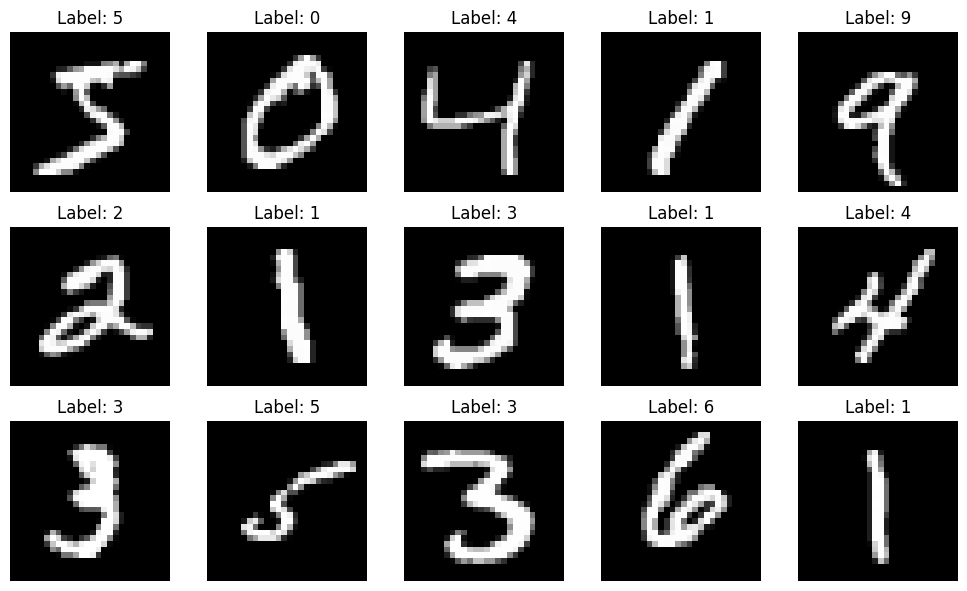

In [4]:
def plot_digits(images, labels, nrows=3, ncols=5):
    plt.figure(figsize=(ncols*2, nrows*2))
    for i in range(nrows*ncols):
        plt.subplot(nrows, ncols, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f'Label: {labels[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_digits(x_train, y_train)

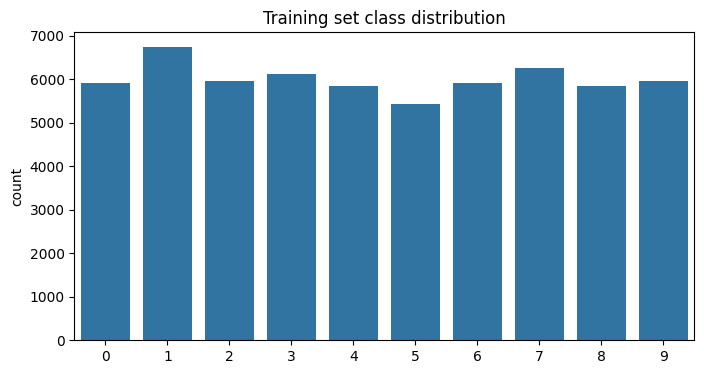

In [5]:
plt.figure(figsize=(8,4))
sns.countplot(x=y_train)
plt.title('Training set class distribution')
plt.show()


In [6]:
# 1. Reshape to (samples, 28, 28, 1) for CNN
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32')
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32')

# 2. Normalize pixel values to [0,1]
x_train /= 255.0
x_test  /= 255.0

# 3. One-hot encode labels
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat  = tf.keras.utils.to_categorical(y_test, 10)

print("After preprocessing:")
print(f"x_train: {x_train.shape}  dtype={x_train.dtype}")
print(f"y_train_cat: {y_train_cat.shape}")

After preprocessing:
x_train: (60000, 28, 28, 1)  dtype=float32
y_train_cat: (60000, 10)


In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(x_train, y_train_cat,
                    validation_data=(x_test, y_test_cat),
                    epochs=10,
                    batch_size=128,
                    verbose=2)

Epoch 1/10
469/469 - 55s - 118ms/step - accuracy: 0.9040 - loss: 0.3123 - val_accuracy: 0.9763 - val_loss: 0.0701
Epoch 2/10
469/469 - 75s - 159ms/step - accuracy: 0.9692 - loss: 0.1051 - val_accuracy: 0.9828 - val_loss: 0.0486
Epoch 3/10
469/469 - 47s - 101ms/step - accuracy: 0.9775 - loss: 0.0764 - val_accuracy: 0.9880 - val_loss: 0.0344
Epoch 4/10
469/469 - 85s - 181ms/step - accuracy: 0.9805 - loss: 0.0648 - val_accuracy: 0.9876 - val_loss: 0.0339
Epoch 5/10
469/469 - 46s - 97ms/step - accuracy: 0.9845 - loss: 0.0528 - val_accuracy: 0.9891 - val_loss: 0.0331
Epoch 6/10
469/469 - 83s - 177ms/step - accuracy: 0.9849 - loss: 0.0477 - val_accuracy: 0.9909 - val_loss: 0.0302
Epoch 7/10
469/469 - 84s - 178ms/step - accuracy: 0.9872 - loss: 0.0414 - val_accuracy: 0.9923 - val_loss: 0.0241
Epoch 8/10
469/469 - 45s - 97ms/step - accuracy: 0.9890 - loss: 0.0356 - val_accuracy: 0.9917 - val_loss: 0.0245
Epoch 9/10
469/469 - 47s - 100ms/step - accuracy: 0.9901 - loss: 0.0319 - val_accuracy: 0.

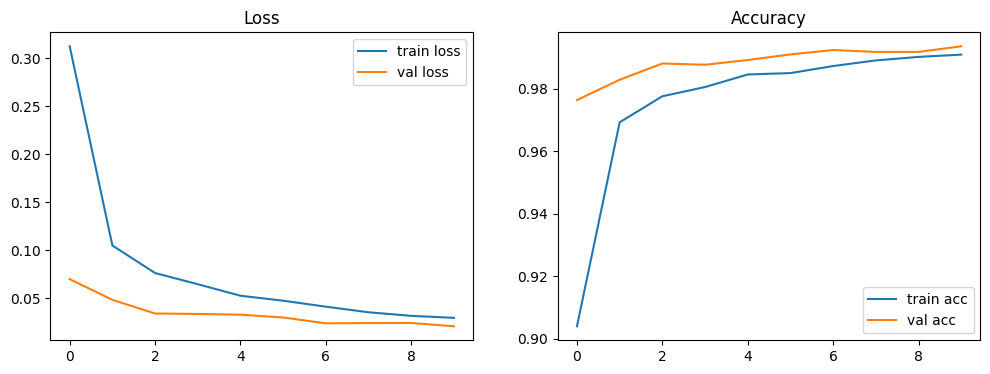

In [10]:
def plot_history(hist):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'], label='train loss')
    plt.plot(hist.history['val_loss'], label='val loss')
    plt.legend(); plt.title('Loss')

    plt.subplot(1,2,2)
    plt.plot(hist.history['accuracy'], label='train acc')
    plt.plot(hist.history['val_accuracy'], label='val acc')
    plt.legend(); plt.title('Accuracy')

    plt.show()

plot_history(history)

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4%}")

Test accuracy: 99.3500%


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


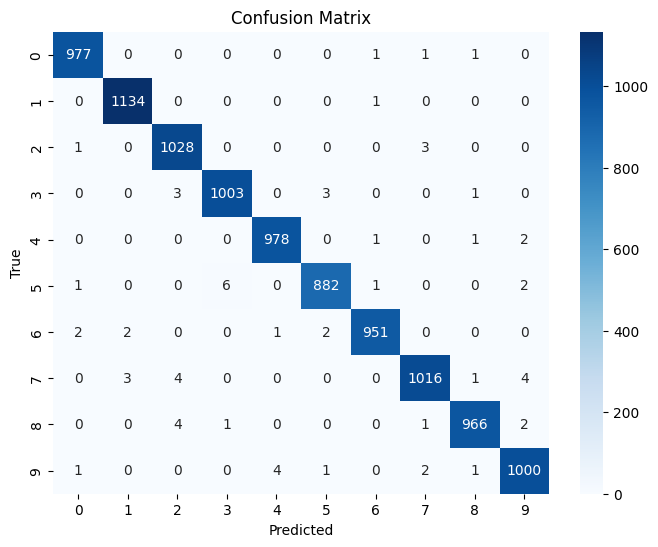

In [12]:
y_pred = np.argmax(model.predict(x_test), axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


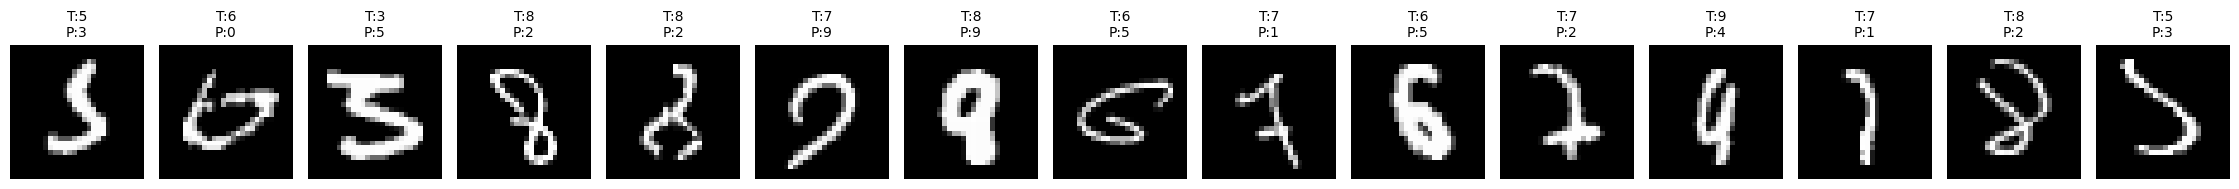

In [13]:
errors = np.where(y_pred != y_test)[0]
n = min(15, len(errors))
plt.figure(figsize=(n*1.5, 3))
for i, idx in enumerate(errors[:n]):
    plt.subplot(1, n, i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f'T:{y_test[idx]}\nP:{y_pred[idx]}', fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()